# Explainable AI for Autonomous Driving

Research-grade BDD100K RWVC pipeline comparing Faster R-CNN with Grad-CAM against ProtoPNet with prototype activations under control and stress weather conditions.


# 0. Setup & Installs


In [18]:
!pip install -q torch torchvision torchmetrics pycocotools grad-cam captum scikit-image seaborn scikit-learn gdown


In [19]:
import os, json, random, warnings
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from captum.attr import IntegratedGradients
from skimage.metrics import structural_similarity as ssim

try:
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception:
    show_cam_on_image = None

sns.set_theme(style="whitegrid")
RNG_SEED = 42
random.seed(RNG_SEED); np.random.seed(RNG_SEED); torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


# 1. Configuration & Constants


In [20]:
DATASET_ROOT = '/kaggle/working/data'
CONTROL_TRAIN_IMGS, CONTROL_TRAIN_LABELS = f'{DATASET_ROOT}/control/images/train', f'{DATASET_ROOT}/control/labels/train'
CONTROL_VAL_IMGS, CONTROL_VAL_LABELS = f'{DATASET_ROOT}/control/images/val', f'{DATASET_ROOT}/control/labels/val'
CONTROL_TEST_IMGS, CONTROL_TEST_LABELS = f'{DATASET_ROOT}/control/images/test', f'{DATASET_ROOT}/control/labels/test'
STRESS_TEST_IMGS, STRESS_TEST_LABELS = f'{DATASET_ROOT}/stress/images/test', f'{DATASET_ROOT}/stress/labels/test'

LABELMAP = {'background': 0, 'car': 1, 'traffic light': 2, 'traffic sign': 3}
LABEL_MAP = LABELMAP
ID_TO_CLASS = {v: k for k, v in LABELMAP.items()}
CLASS_NAMES = [ID_TO_CLASS[i] for i in range(4)]
OBJECT_CLASS_IDS = [1, 2, 3]
NUM_CLASSES = 4
NUM_CLASSES_B = 4
NUM_PROTO = NUM_CLASSES_B * 5
PROTO_DIM = 128
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)
TORCH_MEAN = torch.tensor(MEAN).view(3, 1, 1)
TORCH_STD = torch.tensor(STD).view(3, 1, 1)
MODEL_A_PATH = 'model_a_fasterrcnn.pth'
MODEL_B_PATH = 'model_b_protopnet.pth'

def ensure_dataset_present():
    required = [CONTROL_TRAIN_IMGS, CONTROL_TRAIN_LABELS, CONTROL_TEST_IMGS, CONTROL_TEST_LABELS, STRESS_TEST_IMGS, STRESS_TEST_LABELS]
    missing = [p for p in required if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError("Dataset missing under /kaggle/working/data. Run the optional download cell or mount data. Missing: " + ", ".join(missing))
ensure_dataset_present()


In [21]:
# # Optional dataset download helper. Run only if /kaggle/working/data is absent.
# import gdown
# file_id = '1x3l0D95_FtNiUOrN4ErTLkVxmukaYhrh'
# gdown.download(f'https://drive.google.com/uc?id={file_id}', 'new_dataset.zip', quiet=False)
# !unzip -q new_dataset.zip -d /kaggle/working/data


# 2. Dataset Pipeline


In [22]:
class PerImageJSONDataset(Dataset):
    """Detection dataset reading per-image BDD100K frames -> objects -> box2d JSON."""
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir, self.label_dir, self.transform = img_dir, label_dir, transform
        self.samples = []
        for fname in sorted(os.listdir(img_dir)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                stem = os.path.splitext(fname)[0]
                json_path = os.path.join(label_dir, stem + '.json')
                if os.path.exists(json_path):
                    self.samples.append((fname, json_path))
        print(f"Loaded {len(self.samples)} matched image-label pairs from {img_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, json_path = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        W, H = img.size
        with open(json_path) as f:
            data = json.load(f)
        boxes, labels = [], []
        for frame in data.get("frames", []):
            for obj in frame.get("objects", []):
                label_id = LABELMAP.get(obj.get("category"))
                box = obj.get("box2d")
                if label_id is None or not box:
                    continue
                x1, y1, x2, y2 = float(box["x1"]), float(box["y1"]), float(box["x2"]), float(box["y2"])
                x1, y1 = max(0.0, min(x1, W)), max(0.0, min(y1, H))
                x2, y2 = max(0.0, min(x2, W)), max(0.0, min(y2, H))
                if x2 - x1 < 1.0 or y2 - y1 < 1.0:
                    continue
                boxes.append([x1, y1, x2, y2]); labels.append(label_id)
        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx], dtype=torch.int64)}
        if self.transform:
            img = self.transform(img)
        return img, target


class BDDClassDataset(Dataset):
    """Classification dataset using the first non-background object as dominant class."""
    def __init__(self, img_dir, label_dir, transform=None):
        self.transform, self.samples = transform, []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            stem = os.path.splitext(fname)[0]
            json_path = os.path.join(label_dir, stem + '.json')
            if not os.path.exists(json_path):
                continue
            with open(json_path) as f:
                data = json.load(f)
            label = 0
            for frame in data.get("frames", []):
                for obj in frame.get("objects", []):
                    mapped = LABELMAP.get(obj.get("category"))
                    if mapped is not None and mapped != 0:
                        label = mapped; break
                if label != 0:
                    break
            self.samples.append((os.path.join(img_dir, fname), label))
        print(f"ClassDataset: {len(self.samples)} images from {img_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [23]:
proto_transform_train = T.Compose([
    T.Resize((224, 224)), T.RandomHorizontalFlip(0.5), T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
proto_transform_test = T.Compose([
    T.Resize((224, 224)), T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
detection_transform_train = T.Compose([T.ToTensor()])
detection_transform_test = T.Compose([T.ToTensor()])
collate_fn = lambda batch: tuple(zip(*batch))

train_B = BDDClassDataset(CONTROL_TRAIN_IMGS, CONTROL_TRAIN_LABELS, proto_transform_train)
val_B = BDDClassDataset(CONTROL_VAL_IMGS, CONTROL_VAL_LABELS, proto_transform_test)
ctrl_B = BDDClassDataset(CONTROL_TEST_IMGS, CONTROL_TEST_LABELS, proto_transform_test)
stress_B = BDDClassDataset(STRESS_TEST_IMGS, STRESS_TEST_LABELS, proto_transform_test)
full_train_B, full_val_B, full_ctrl_B, full_stress_B = train_B, val_B, ctrl_B, stress_B

train_loader_B = DataLoader(train_B, batch_size=16, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader_B = DataLoader(val_B, batch_size=16, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
ctrl_loader_B = DataLoader(ctrl_B, batch_size=16, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
stress_loader_B = DataLoader(stress_B, batch_size=16, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

train_det = PerImageJSONDataset(CONTROL_TRAIN_IMGS, CONTROL_TRAIN_LABELS, detection_transform_train)
val_det = PerImageJSONDataset(CONTROL_VAL_IMGS, CONTROL_VAL_LABELS, detection_transform_test)
ctrl_det = PerImageJSONDataset(CONTROL_TEST_IMGS, CONTROL_TEST_LABELS, detection_transform_test)
stress_det = PerImageJSONDataset(STRESS_TEST_IMGS, STRESS_TEST_LABELS, detection_transform_test)
train_loader_det = DataLoader(train_det, batch_size=4, shuffle=True, num_workers=2, collate_fn=collate_fn, pin_memory=torch.cuda.is_available())
val_loader_det = DataLoader(val_det, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=torch.cuda.is_available())
ctrl_loader_det = DataLoader(ctrl_det, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=torch.cuda.is_available())
stress_loader_det = DataLoader(stress_det, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=torch.cuda.is_available())
if len(train_B) < 500:
    warnings.warn(f"Small control training dataset: {len(train_B)} samples")


ClassDataset: 1973 images from /kaggle/working/data/control/images/train
ClassDataset: 561 images from /kaggle/working/data/control/images/val
ClassDataset: 448 images from /kaggle/working/data/control/images/test
ClassDataset: 1552 images from /kaggle/working/data/stress/images/test
Loaded 1973 matched image-label pairs from /kaggle/working/data/control/images/train
Loaded 561 matched image-label pairs from /kaggle/working/data/control/images/val
Loaded 448 matched image-label pairs from /kaggle/working/data/control/images/test
Loaded 1552 matched image-label pairs from /kaggle/working/data/stress/images/test


# 3. Faster R-CNN: Model + Training


In [24]:
def build_fasterrcnn(num_classes=NUM_CLASSES):
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def train_fasterrcnn(model, loader, device, epochs=5, save_path=MODEL_A_PATH):
    model.to(device)
    optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad], lr=0.005, momentum=0.9, weight_decay=0.0005)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
    history = []
    for epoch in range(epochs):
        model.train(); total = 0.0; n = 0
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
            optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
            total += float(loss.detach().cpu()); n += 1
        scheduler.step()
        history.append(total / max(n, 1))
        print(f"Faster R-CNN epoch {epoch+1}/{epochs}: loss={history[-1]:.4f}")
    torch.save(model.state_dict(), save_path)
    return history

model_A = build_fasterrcnn(NUM_CLASSES).to(device)
fasterrcnn_loss_history = []
if os.path.exists(MODEL_A_PATH):
    model_A.load_state_dict(torch.load(MODEL_A_PATH, map_location=device))
    print("Loaded", MODEL_A_PATH)
else:
    fasterrcnn_loss_history = train_fasterrcnn(model_A, train_loader_det, device)


Loaded model_a_fasterrcnn.pth


# 4. ProtoPNet: Model + Training


In [25]:
class ProtoPNetBDD(nn.Module):
    def __init__(self, num_classes, num_prototypes, proto_dim=128):
        super().__init__()
        self.num_classes, self.num_prototypes = num_classes, num_prototypes
        backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-2])
        self.add_on_layers = nn.Sequential(nn.Conv2d(2048, 256, 1), nn.ReLU(), nn.Conv2d(256, proto_dim, 1), nn.Sigmoid())
        self.prototype_vectors = nn.Parameter(torch.rand(num_prototypes, proto_dim, 1, 1), requires_grad=True)
        self.last_layer = nn.Linear(num_prototypes, num_classes, bias=False)

    def conv_features(self, x):
        return self.add_on_layers(self.features(x))

    def prototype_distances(self, x):
        xp = F.conv2d(x ** 2, torch.ones_like(self.prototype_vectors))
        p2 = (self.prototype_vectors ** 2).sum(dim=(1,2,3)).view(-1,1,1)
        xpT = F.conv2d(x, self.prototype_vectors)
        return xp - 2 * xpT + p2

    def forward(self, x):
        feats = self.conv_features(x)
        dists = self.prototype_distances(feats)
        min_dists = -F.max_pool2d(-dists, kernel_size=(dists.size(2), dists.size(3))).view(-1, self.num_prototypes)
        sims = torch.log((min_dists + 1) / (min_dists + 1e-4))
        logits = self.last_layer(sims)
        return logits, min_dists

def prototype_push(model, loader, device):
    model.eval()
    best, best_dist = [None] * model.num_prototypes, [float("inf")] * model.num_prototypes
    with torch.no_grad():
        for imgs, _ in loader:
            feats = model.conv_features(imgs.to(device)); dists = model.prototype_distances(feats)
            for p in range(model.num_prototypes):
                dm = dists[:, p]
                val, flat = dm.reshape(-1).min(0)
                if val.item() < best_dist[p]:
                    best_dist[p] = val.item()
                    spatial = dm.shape[1] * dm.shape[2]
                    b, rem = flat.item() // spatial, flat.item() % spatial
                    y, x = rem // dm.shape[2], rem % dm.shape[2]
                    best[p] = feats[b:b+1, :, y:y+1, x:x+1].detach().clone()
    with torch.no_grad():
        for p, patch in enumerate(best):
            if patch is not None:
                model.prototype_vectors[p].copy_(patch.squeeze(0))
    print("Prototype push done")

def train_protopnet(model, loader, device, save_path=MODEL_B_PATH):
    history = {"warmup": [], "joint": [], "last": []}
    for p in model.features.parameters(): p.requires_grad = False
    opt = torch.optim.Adam([
        {"params": model.add_on_layers.parameters(), "lr": 3e-3},
        {"params": [model.prototype_vectors], "lr": 3e-3},
        {"params": model.last_layer.parameters(), "lr": 3e-3},
    ])
    for epoch in range(5):
        model.train(); total = 0; n = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, min_dists = model(imgs)
            loss = F.cross_entropy(logits, labels) + 0.8 * min_dists.min(dim=0).values.mean()
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += float(loss.detach().cpu()); n += 1
        history["warmup"].append(total / max(n, 1)); print("warmup", epoch + 1, history["warmup"][-1])
    for p in model.features.parameters(): p.requires_grad = True
    opt = torch.optim.Adam([
        {"params": model.features.parameters(), "lr": 1e-4},
        {"params": model.add_on_layers.parameters(), "lr": 3e-3},
        {"params": [model.prototype_vectors], "lr": 3e-3},
        {"params": model.last_layer.parameters(), "lr": 3e-3},
    ])
    for epoch in range(5):
        model.train(); total = 0; n = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, min_dists = model(imgs)
            ce = F.cross_entropy(logits, labels)
            clst = min_dists.min(dim=0).values.mean()
            sep = -min_dists.topk(k=2, dim=1, largest=False).values[:,1].mean()
            loss = ce + 0.8 * clst - 0.08 * sep
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += float(loss.detach().cpu()); n += 1
        history["joint"].append(total / max(n, 1)); print("joint", epoch + 1, history["joint"][-1])
    prototype_push(model, loader, device)
    for p in model.parameters(): p.requires_grad = False
    for p in model.last_layer.parameters(): p.requires_grad = True
    opt = torch.optim.Adam(model.last_layer.parameters(), lr=1e-4)
    for epoch in range(5):
        model.train(); total = 0; n = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = model(imgs)
            loss = F.cross_entropy(logits, labels)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += float(loss.detach().cpu()); n += 1
        history["last"].append(total / max(n, 1)); print("last", epoch + 1, history["last"][-1])
    torch.save(model.state_dict(), save_path)
    return history

model_B = ProtoPNetBDD(NUM_CLASSES_B, NUM_PROTO, PROTO_DIM).to(device)
protopnet_loss_history = {"warmup": [], "joint": [], "last": []}
if os.path.exists(MODEL_B_PATH):
    model_B.load_state_dict(torch.load(MODEL_B_PATH, map_location=device))
    print("Loaded", MODEL_B_PATH)
else:
    protopnet_loss_history = train_protopnet(model_B, train_loader_B, device)


Loaded model_b_protopnet.pth


# 5. Evaluation Metrics
## 5.1 Faster R-CNN - mAP, Precision, Recall (Control vs Stress)


In [26]:
@torch.no_grad()
def evaluate_detection_map(model, loader, device):
    model.eval(); metric = MeanAveragePrecision(class_metrics=True, iou_type="bbox")
    for images, targets in loader:
        preds = model([x.to(device) for x in images])
        preds = [{k: v.detach().cpu() for k, v in p.items() if k in {"boxes", "scores", "labels"}} for p in preds]
        targets = [{k: v.detach().cpu() for k, v in t.items() if k in {"boxes", "labels"}} for t in targets]
        metric.update(preds, targets)
    return metric.compute()

def summarize_map(result):
    rows = {"mAP@0.50:0.95": float(result["map"]), "mAP@0.50": float(result["map_50"]), "mAP@0.75": float(result["map_75"])}
    class_ids = result.get("classes", torch.tensor(OBJECT_CLASS_IDS)).cpu().numpy().tolist()
    ap_values = result.get("map_per_class", torch.zeros(len(class_ids))).cpu().numpy().tolist()
    for cid, ap in zip(class_ids, ap_values):
        if int(cid) in OBJECT_CLASS_IDS:
            rows[f"AP {ID_TO_CLASS[int(cid)]}"] = float(ap)
    return rows

def precision_recall_per_class_iou50(model, loader, device, score_threshold=0.05):
    stats = {cid: {"tp": 0, "fp": 0, "fn": 0} for cid in OBJECT_CLASS_IDS}
    model.eval()
    with torch.no_grad():
        for images, targets in loader:
            preds = model([x.to(device) for x in images])
            for pred, target in zip(preds, targets):
                keep = pred["scores"].detach().cpu() >= score_threshold
                p_boxes, p_labels, p_scores = pred["boxes"].detach().cpu()[keep], pred["labels"].detach().cpu()[keep], pred["scores"].detach().cpu()[keep]
                order = torch.argsort(p_scores, descending=True); p_boxes, p_labels = p_boxes[order], p_labels[order]
                t_boxes, t_labels = target["boxes"].detach().cpu(), target["labels"].detach().cpu()
                for cid in OBJECT_CLASS_IDS:
                    pb, tb = p_boxes[p_labels == cid], t_boxes[t_labels == cid]
                    matched = set()
                    for box in pb:
                        if len(tb) == 0:
                            stats[cid]["fp"] += 1; continue
                        ious = box_iou(box.unsqueeze(0), tb).squeeze(0)
                        best_iou, best_idx = torch.max(ious, dim=0)
                        if float(best_iou) >= 0.5 and int(best_idx) not in matched:
                            stats[cid]["tp"] += 1; matched.add(int(best_idx))
                        else:
                            stats[cid]["fp"] += 1
                    stats[cid]["fn"] += max(len(tb) - len(matched), 0)
    rows = []
    for cid, s in stats.items():
        rows.append({"class": ID_TO_CLASS[cid], "precision@0.5": s["tp"] / max(s["tp"] + s["fp"], 1), "recall@0.5": s["tp"] / max(s["tp"] + s["fn"], 1), **s})
    return pd.DataFrame(rows)

ctrl_map_result = evaluate_detection_map(model_A, ctrl_loader_det, device)
stress_map_result = evaluate_detection_map(model_A, stress_loader_det, device)
faster_map_table = pd.DataFrame([{"condition": "Control", **summarize_map(ctrl_map_result)}, {"condition": "Stress", **summarize_map(stress_map_result)}])
display(faster_map_table)
faster_pr_table = precision_recall_per_class_iou50(model_A, ctrl_loader_det, device).merge(
    precision_recall_per_class_iou50(model_A, stress_loader_det, device), on="class", suffixes=("_control", "_stress")
)
display(faster_pr_table)


,condition,mAP@0.50:0.95,mAP@0.50,mAP@0.75,AP car,AP traffic light,AP traffic sign
0,Control,0.263186,0.547450,0.228865,0.384169,0.164455,0.240933
1,Stress,0.249197,0.530103,0.208358,0.380736,0.145628,0.221227


,class,precision@0.5_control,recall@0.5_control,tp_control,fp_control,fn_control,precision@0.5_stress,recall@0.5_stress,tp_stress,fp_stress,fn_stress
0,car,0.183749,0.845044,4041,17951,741,0.166608,0.841833,11901,59530,2236
1,traffic light,0.153473,0.721715,791,4363,305,0.148331,0.707916,3461,19872,1428
2,traffic sign,0.169433,0.729513,1184,5804,439,0.135792,0.736388,3841,24445,1375


## 5.2 ProtoPNet - Accuracy, F1, Confusion Matrix (Control vs Stress)


Control acc=0.502 | Stress acc=0.430 | Drop=0.072


,condition,class,precision,recall,f1,support
0,Control,background,0.000000,0.000000,0.000000,1
1,Control,car,0.496000,0.894231,0.638079,208
2,Control,traffic light,0.574468,0.252336,0.350649,107
3,Control,traffic sign,0.461538,0.090909,0.151899,132
4,Control,macro avg,0.383002,0.309369,0.285157,448
5,Control,weighted avg,0.503480,0.502232,0.424756,448
6,Stress,background,0.000000,0.000000,0.000000,0
7,Stress,car,0.433191,0.790373,0.559648,644
8,Stress,traffic light,0.401316,0.279817,0.329730,436
9,Stress,traffic sign,0.506849,0.078390,0.135780,472


               precision    recall  f1-score   support

   background       0.00      0.00      0.00         1
          car       0.50      0.89      0.64       208
traffic light       0.57      0.25      0.35       107
 traffic sign       0.46      0.09      0.15       132

     accuracy                           0.50       448
    macro avg       0.38      0.31      0.29       448
 weighted avg       0.50      0.50      0.42       448

               precision    recall  f1-score   support

   background       0.00      0.00      0.00         0
          car       0.43      0.79      0.56       644
traffic light       0.40      0.28      0.33       436
 traffic sign       0.51      0.08      0.14       472

     accuracy                           0.43      1552
    macro avg       0.34      0.29      0.26      1552
 weighted avg       0.45      0.43      0.37      1552



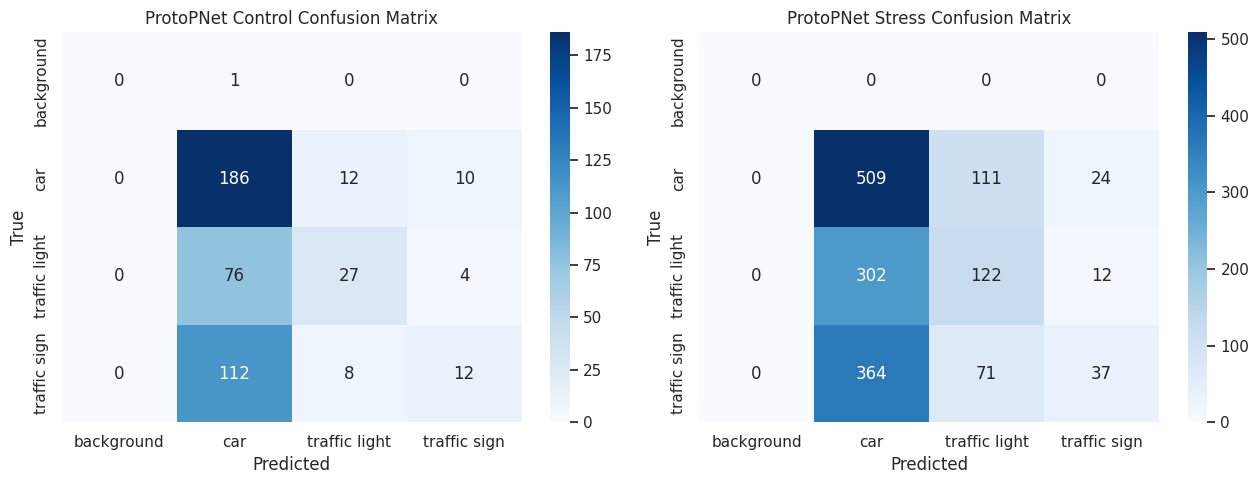

In [27]:
@torch.no_grad()
def predict_protopnet(model, loader, device):
    model.eval(); y_true, y_pred, y_score = [], [], []
    for imgs, labels in loader:
        logits, _ = model(imgs.to(device)); probs = torch.softmax(logits, dim=1)
        y_true.extend(labels.cpu().numpy().tolist()); y_pred.extend(logits.argmax(1).cpu().numpy().tolist()); y_score.extend(probs.max(1).values.cpu().numpy().tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_score)

def eval_acc(model, loader, device):
    y, p, _ = predict_protopnet(model, loader, device)
    return float(accuracy_score(y, p)) if len(y) else 0.0

def classification_metrics_table(y_true, y_pred, condition):
    p, r, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=list(range(NUM_CLASSES_B)), zero_division=0)
    rows = [{"condition": condition, "class": CLASS_NAMES[i], "precision": p[i], "recall": r[i], "f1": f1[i], "support": support[i]} for i in range(NUM_CLASSES_B)]
    macro = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    weighted = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    rows += [
        {"condition": condition, "class": "macro avg", "precision": macro[0], "recall": macro[1], "f1": macro[2], "support": len(y_true)},
        {"condition": condition, "class": "weighted avg", "precision": weighted[0], "recall": weighted[1], "f1": weighted[2], "support": len(y_true)},
    ]
    return pd.DataFrame(rows)

ctrl_true_B, ctrl_pred_B, ctrl_score_B = predict_protopnet(model_B, ctrl_loader_B, device)
stress_true_B, stress_pred_B, stress_score_B = predict_protopnet(model_B, stress_loader_B, device)
acc_ctrl, acc_stress = float(accuracy_score(ctrl_true_B, ctrl_pred_B)), float(accuracy_score(stress_true_B, stress_pred_B))
print(f"Control acc={acc_ctrl:.3f} | Stress acc={acc_stress:.3f} | Drop={acc_ctrl - acc_stress:.3f}")
proto_metrics_table = pd.concat([classification_metrics_table(ctrl_true_B, ctrl_pred_B, "Control"), classification_metrics_table(stress_true_B, stress_pred_B, "Stress")], ignore_index=True)
display(proto_metrics_table)
print(classification_report(ctrl_true_B, ctrl_pred_B, labels=list(range(NUM_CLASSES_B)), target_names=CLASS_NAMES, zero_division=0))
print(classification_report(stress_true_B, stress_pred_B, labels=list(range(NUM_CLASSES_B)), target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for axis, y, p, title in [(ax[0], ctrl_true_B, ctrl_pred_B, "Control"), (ax[1], stress_true_B, stress_pred_B, "Stress")]:
    cm = confusion_matrix(y, p, labels=list(range(NUM_CLASSES_B)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axis)
    axis.set_title(f"ProtoPNet {title} Confusion Matrix"); axis.set_xlabel("Predicted"); axis.set_ylabel("True")
plt.tight_layout(); plt.show()


# 6. Explainability
## 6.1 Faster R-CNN - Grad-CAM
## 6.2 ProtoPNet - Prototype Activations
## 6.3 Integrated Gradients (Captum) - Both Models


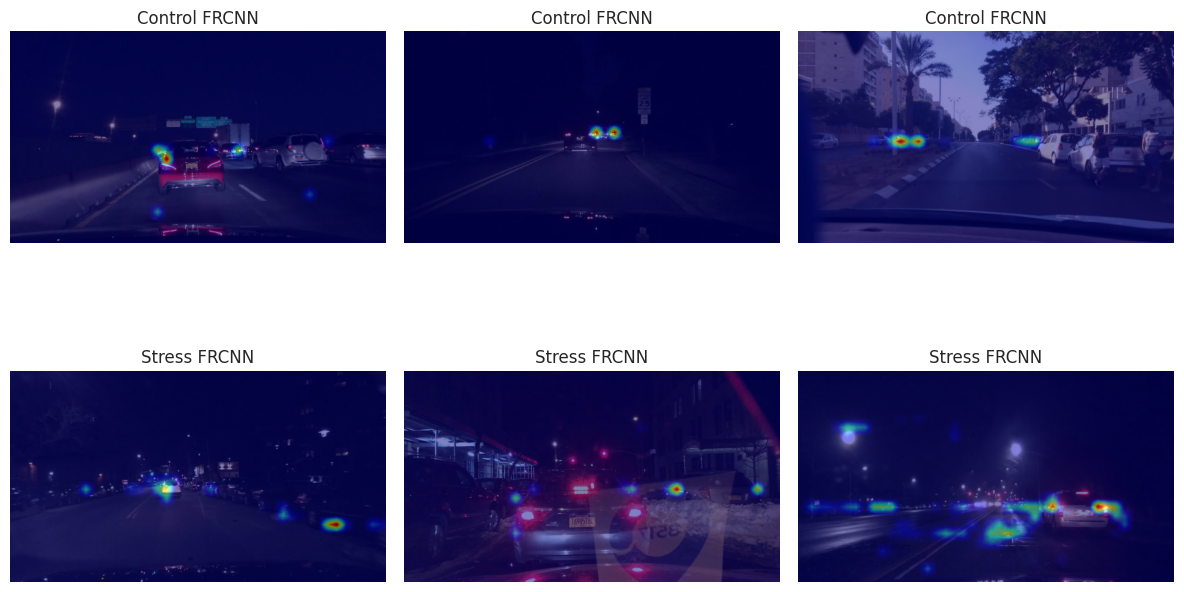

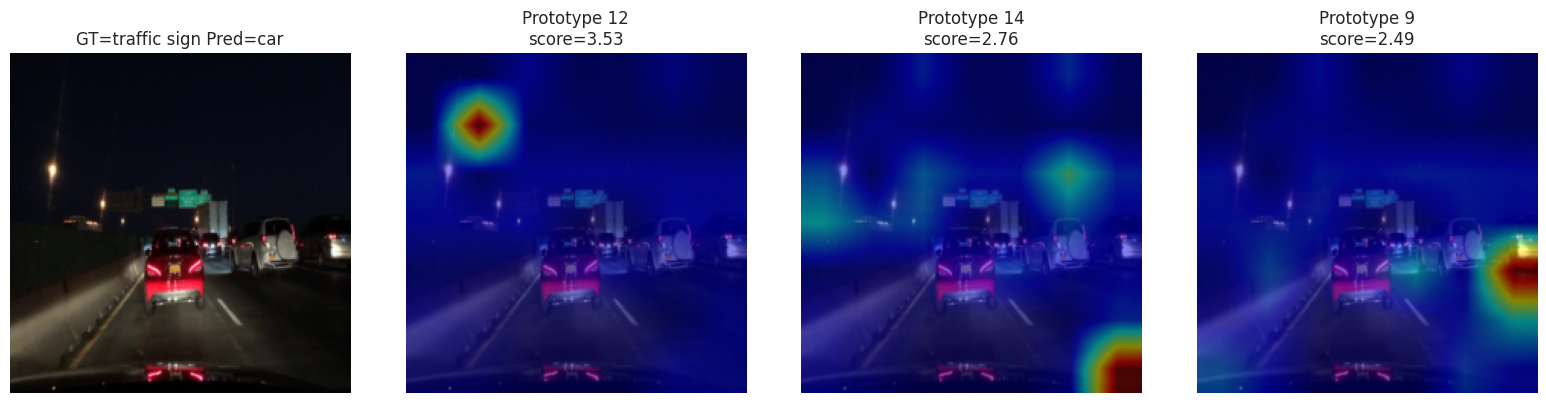

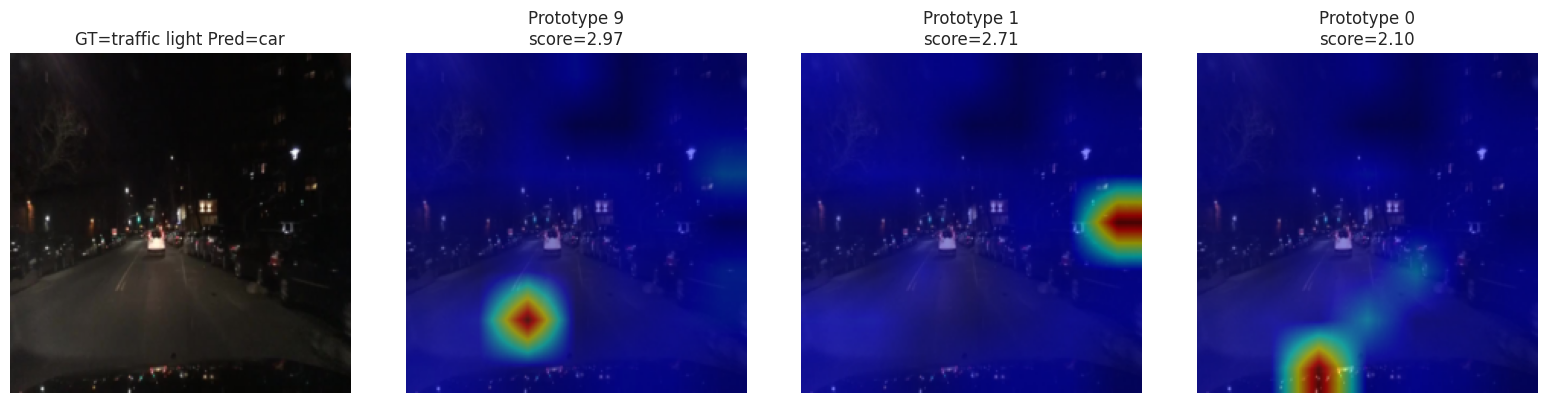

In [28]:
def tensor_to_rgb(img_tensor, normalized=False):
    img = img_tensor.detach().cpu()
    if normalized:
        img = img * TORCH_STD + TORCH_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy().astype(np.float32)

def normalize_map(arr):
    arr = np.asarray(arr, dtype=np.float32)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

def overlay_heatmap(img_rgb, saliency, alpha=0.40):
    sal = cv2.resize(normalize_map(saliency), (img_rgb.shape[1], img_rgb.shape[0]))
    if show_cam_on_image is not None:
        return show_cam_on_image(img_rgb.astype(np.float32), sal, use_rgb=True)
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * sal), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(np.uint8(255 * img_rgb), 1 - alpha, heat, alpha, 0)

def grad_cam_fasterrcnn(model, img_tensor, device):
    model.eval(); activations, gradients = [], []; layer = model.backbone.body.layer4
    h1 = layer.register_forward_hook(lambda m, i, o: activations.append(o))
    h2 = layer.register_full_backward_hook(lambda m, gi, go: gradients.append(go[0]))
    try:
        out = model([img_tensor.to(device)])[0]
        if len(out["scores"]) == 0:
            return np.zeros(img_tensor.shape[1:], dtype=np.float32), tensor_to_rgb(img_tensor), None
        idx = int(torch.argmax(out["scores"]).item()); score = out["scores"][idx]
        model.zero_grad(set_to_none=True); score.backward()
        weights = gradients[-1].detach().mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * activations[-1].detach()).sum(dim=1)).squeeze(0).cpu().numpy()
        info = {"label": int(out["labels"][idx].detach().cpu()), "score": float(score.detach().cpu())}
        return normalize_map(cam), overlay_heatmap(tensor_to_rgb(img_tensor), cam), info
    finally:
        h1.remove(); h2.remove()

def protopnet_saliency_map(model, img_tensor, device):
    model.eval()
    with torch.no_grad():
        x = img_tensor.unsqueeze(0).to(device)
        feats = model.conv_features(x); dists = model.prototype_distances(feats)
        sims = torch.log((dists + 1.0) / (dists + 1e-4))
        max_sims = sims.flatten(2).max(dim=2).values[0]
        proto_idx = int(torch.argmax(max_sims).item())
        logits, _ = model(x); pred = int(logits.argmax(1).item())
    sal = cv2.resize(normalize_map(sims[0, proto_idx].cpu().numpy()), (img_tensor.shape[2], img_tensor.shape[1]))
    return sal, {"prototype": proto_idx, "pred": pred}

def get_attention_map(model, dataset, idx, device):
    img, _ = dataset[idx]; sal, _ = protopnet_saliency_map(model, img, device)
    return overlay_heatmap(tensor_to_rgb(img, normalized=True), sal)

def explain_prediction(model, dataset, idx, device, top_k=3):
    img, label = dataset[idx]; x = img.unsqueeze(0).to(device); model.eval()
    with torch.no_grad():
        feats = model.conv_features(x); dists = model.prototype_distances(feats)
        sims = torch.log((dists + 1) / (dists + 1e-4)); logits, _ = model(x)
        vals, protos = torch.topk(sims.flatten(2).max(dim=2).values[0], k=top_k)
    rgb = tensor_to_rgb(img, normalized=True)
    fig, ax = plt.subplots(1, top_k + 1, figsize=(4 * (top_k + 1), 4))
    ax[0].imshow(rgb); ax[0].set_title(f"GT={ID_TO_CLASS[label]} Pred={ID_TO_CLASS[int(logits.argmax(1).item())]}"); ax[0].axis("off")
    for i, proto in enumerate(protos):
        p = int(proto.item()); sal = cv2.resize(normalize_map(sims[0, p].cpu().numpy()), (rgb.shape[1], rgb.shape[0]))
        ax[i+1].imshow(overlay_heatmap(rgb, sal)); ax[i+1].set_title(f"Prototype {p}\nscore={float(vals[i]):.2f}"); ax[i+1].axis("off")
    plt.tight_layout(); plt.show()

class ProtoLogitWrapper(nn.Module):
    def __init__(self, model): super().__init__(); self.model = model
    def forward(self, x): return self.model(x)[0]

class FasterBackboneScalarWrapper(nn.Module):
    def __init__(self, model): super().__init__(); self.model = model
    def forward(self, x):
        feats = self.model.backbone(x)
        feat = feats["0"] if isinstance(feats, dict) else feats
        return feat.mean(dim=(1,2,3)).unsqueeze(1)

def integrated_gradients_protopnet(model, img_tensor, device, target=None, steps=24):
    wrapper = ProtoLogitWrapper(model).to(device); x = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    if target is None:
        with torch.no_grad(): target = int(wrapper(x).argmax(1).item())
    attr = IntegratedGradients(wrapper).attribute(x, baselines=torch.zeros_like(x), target=target, n_steps=steps)
    return normalize_map(attr.abs().sum(dim=1).squeeze(0).detach().cpu().numpy()), target

def integrated_gradients_fasterrcnn_backbone(model, img_tensor, device, steps=16):
    wrapper = FasterBackboneScalarWrapper(model).to(device); x = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    attr = IntegratedGradients(wrapper).attribute(x, baselines=torch.zeros_like(x), target=0, n_steps=steps)
    return normalize_map(attr.abs().sum(dim=1).squeeze(0).detach().cpu().numpy())

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for row, (ds, title) in enumerate([(ctrl_det, "Control FRCNN"), (stress_det, "Stress FRCNN")]):
    for col, idx in enumerate(np.linspace(0, len(ds)-1, 3, dtype=int)):
        _, overlay, info = grad_cam_fasterrcnn(model_A, ds[int(idx)][0], device)
        ax[row, col].imshow(overlay); ax[row, col].set_title(title); ax[row, col].axis("off")
plt.tight_layout(); plt.show()
explain_prediction(model_B, full_ctrl_B, min(0, len(full_ctrl_B)-1), device)
explain_prediction(model_B, full_stress_B, min(0, len(full_stress_B)-1), device)


# 7. Future Work Experiments


## 7.1 Drop Test
## 7.2 Weather Ablation
## 7.3 Causal Re-evaluation (Attention Shift)
## 7.4 Explanation Drift Metric


,model,condition,mean,std,count
0,fasterrcnn,Control,0.900871,0.305113,20
1,fasterrcnn,Stress,0.858276,0.346234,20
2,proto,Control,0.064595,0.100654,20
3,proto,Stress,0.085542,0.118712,20


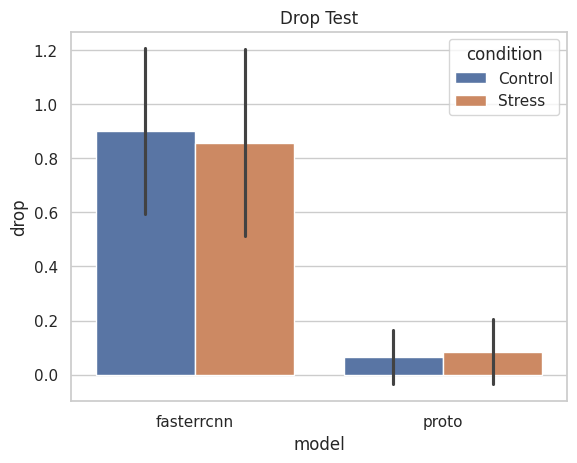

,model,metric,Control,Stress,Cleaned Stress
0,Faster R-CNN,mAP@0.50:0.95,0.263186,0.249197,0.223084
1,ProtoPNet,Accuracy,0.502232,0.430412,0.413015


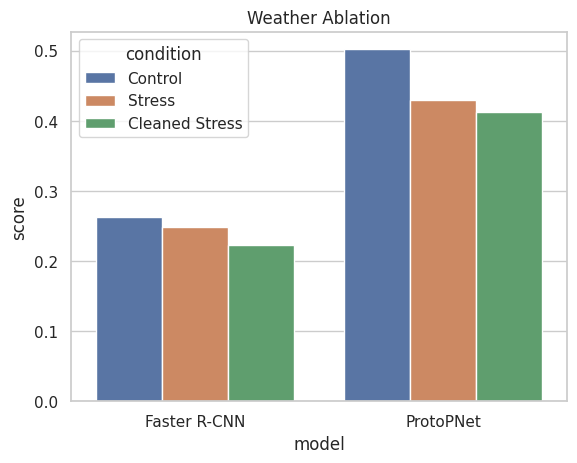

,model,mean,std,count
0,fasterrcnn,0.336136,0.318411,20
1,proto,0.480096,0.182405,20


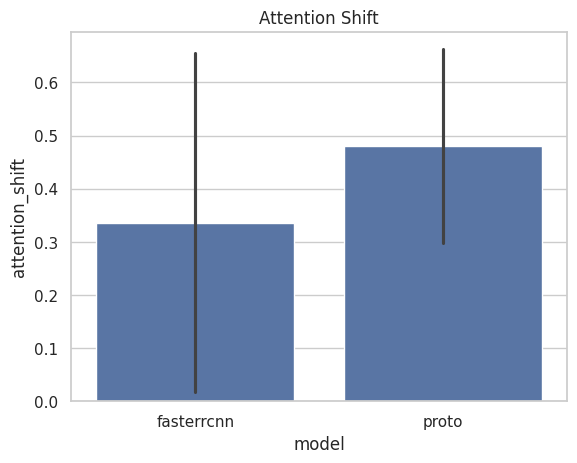

,model,mean_ssim,mean_cosine_similarity,drift_score
0,fasterrcnn,0.837170,0.053569,0.946431
1,proto,0.542947,0.500713,0.499287


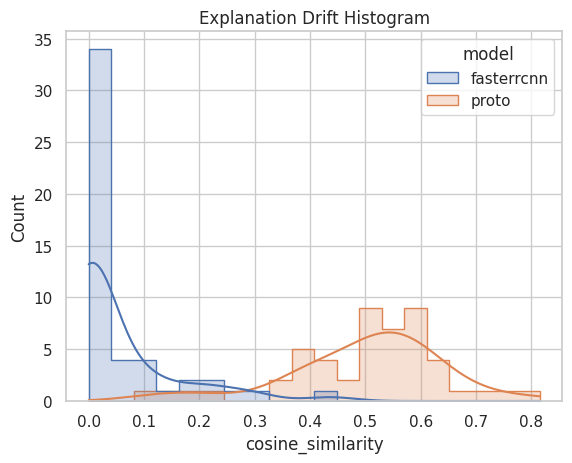

In [29]:
def mask_top_salient_pixels(img_tensor, saliency, k_percent=0.2, normalized=False):
    masked = img_tensor.detach().clone(); h, w = masked.shape[-2:]
    sal = cv2.resize(normalize_map(saliency), (w, h)); mask = torch.tensor(sal >= np.quantile(sal, 1 - k_percent), dtype=torch.bool)
    fill = torch.zeros(3, 1) if normalized else torch.tensor([0.485, 0.456, 0.406]).view(3, 1)
    masked[:, mask] = fill.to(masked.device).expand(3, int(mask.sum()))
    return masked

@torch.no_grad()
def protopnet_top_score(model, img, device):
    probs = torch.softmax(model(img.unsqueeze(0).to(device))[0], dim=1)[0]; pred = int(probs.argmax())
    return float(probs[pred].cpu()), pred

@torch.no_grad()
def fasterrcnn_top_score(model, img, device):
    pred = model([img.to(device)])[0]
    if len(pred["scores"]) == 0: return 0.0, 0
    idx = int(torch.argmax(pred["scores"]))
    return float(pred["scores"][idx].cpu()), int(pred["labels"][idx].cpu())

def drop_test(model, dataset, idx, device, k_percent=0.2, model_type="proto"):
    img, _ = dataset[idx]
    if model_type == "proto":
        sal, _ = protopnet_saliency_map(model, img, device); orig, _ = protopnet_top_score(model, img, device)
        masked = mask_top_salient_pixels(img, sal, k_percent, normalized=True); masked_score, _ = protopnet_top_score(model, masked, device)
    else:
        sal, _, _ = grad_cam_fasterrcnn(model, img, device); orig, _ = fasterrcnn_top_score(model, img, device)
        masked = mask_top_salient_pixels(img, sal, k_percent, normalized=False); masked_score, _ = fasterrcnn_top_score(model, masked, device)
    return {"idx": idx, "original_score": orig, "masked_score": masked_score, "drop": 0.0 if orig <= 1e-8 else float((orig - masked_score) / orig)}

def run_drop_tests(model, dataset, device, model_type, condition, n=20):
    rows = []
    for idx in random.sample(range(len(dataset)), k=min(n, len(dataset))):
        row = drop_test(model, dataset, idx, device, model_type=model_type); row.update({"model": model_type, "condition": condition}); rows.append(row)
    return pd.DataFrame(rows)

def simulate_adverse_weather(img_tensor, severity=0.3):
    img = (img_tensor.detach().clone().clamp(0, 1) + torch.randn_like(img_tensor) * severity * 0.20).clamp(0, 1)
    pil = T.ToPILImage()(img.cpu()).filter(ImageFilter.GaussianBlur(radius=max(0.1, severity * 2.0)))
    return T.ToTensor()(pil)

def simulate_derain(img_tensor, sigma=1.5):
    normalized = bool(img_tensor.min() < 0 or img_tensor.max() > 1)
    img = tensor_to_rgb(img_tensor, normalized=normalized)
    clean = cv2.GaussianBlur(img, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
    out = torch.from_numpy(clean).permute(2, 0, 1).float().clamp(0, 1)
    return (out - TORCH_MEAN) / TORCH_STD if normalized else out

class TransformedTensorDataset(Dataset):
    def __init__(self, base, fn): self.base, self.fn = base, fn
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        img, target = self.base[idx]
        return self.fn(img), target

def cosine_distance_maps(a, b):
    a, b = normalize_map(a).reshape(-1), normalize_map(b).reshape(-1)
    return 1.0 - float(np.dot(a, b) / ((np.linalg.norm(a) * np.linalg.norm(b)) + 1e-8))

def saliency_for_model(model, img, device, model_type):
    if model_type == "proto": return protopnet_saliency_map(model, img, device)[0]
    return cv2.resize(grad_cam_fasterrcnn(model, img, device)[0], (img.shape[2], img.shape[1]))

def attention_shift_analysis(model, dataset, cleaned_dataset, device, model_type, n=20):
    rows = []
    for idx in random.sample(range(len(dataset)), k=min(n, len(dataset))):
        img, _ = dataset[idx]; cleaned, _ = cleaned_dataset[idx]
        rows.append({"idx": idx, "model": model_type, "attention_shift": cosine_distance_maps(saliency_for_model(model, img, device, model_type), saliency_for_model(model, cleaned, device, model_type))})
    return pd.DataFrame(rows)

def explanation_drift(model, ctrl_dataset, stress_dataset, n_samples=50, device=device, model_type="proto"):
    n = min(n_samples, len(ctrl_dataset), len(stress_dataset)); rows = []
    for ci, si in zip(random.sample(range(len(ctrl_dataset)), n), random.sample(range(len(stress_dataset)), n)):
        c = cv2.resize(saliency_for_model(model, ctrl_dataset[ci][0], device, model_type), (224, 224))
        s = cv2.resize(saliency_for_model(model, stress_dataset[si][0], device, model_type), (224, 224))
        cos = 1.0 - cosine_distance_maps(c, s)
        rows.append({"model": model_type, "ctrl_idx": ci, "stress_idx": si, "cosine_similarity": cos, "ssim": ssim(normalize_map(c), normalize_map(s), data_range=1.0)})
    df = pd.DataFrame(rows)
    return df, {"model": model_type, "mean_ssim": float(df.ssim.mean()), "mean_cosine_similarity": float(df.cosine_similarity.mean()), "drift_score": float(1 - df.cosine_similarity.mean())}

# 7.1 Drop Test
drop_results = pd.concat([
    run_drop_tests(model_A, ctrl_det, device, "fasterrcnn", "Control"),
    run_drop_tests(model_A, stress_det, device, "fasterrcnn", "Stress"),
    run_drop_tests(model_B, full_ctrl_B, device, "proto", "Control"),
    run_drop_tests(model_B, full_stress_B, device, "proto", "Stress"),
], ignore_index=True)
display(drop_results.groupby(["model", "condition"])["drop"].agg(["mean", "std", "count"]).reset_index())
sns.barplot(data=drop_results, x="model", y="drop", hue="condition", errorbar="sd"); plt.title("Drop Test"); plt.show()

# 7.2 Weather Ablation
cleaned_stress_det = TransformedTensorDataset(stress_det, lambda x: simulate_derain(x, 1.5))
cleaned_stress_B = TransformedTensorDataset(full_stress_B, lambda x: simulate_derain(x, 1.5))
cleaned_stress_loader_det = DataLoader(cleaned_stress_det, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)
cleaned_stress_loader_B = DataLoader(cleaned_stress_B, batch_size=16, shuffle=False, num_workers=2)
cleaned_map_result = evaluate_detection_map(model_A, cleaned_stress_loader_det, device)
cleaned_acc = eval_acc(model_B, cleaned_stress_loader_B, device)
weather_ablation_table = pd.DataFrame([
    {"model": "Faster R-CNN", "metric": "mAP@0.50:0.95", "Control": float(ctrl_map_result["map"]), "Stress": float(stress_map_result["map"]), "Cleaned Stress": float(cleaned_map_result["map"])},
    {"model": "ProtoPNet", "metric": "Accuracy", "Control": acc_ctrl, "Stress": acc_stress, "Cleaned Stress": cleaned_acc},
])
display(weather_ablation_table)
sns.barplot(data=weather_ablation_table.melt(id_vars=["model", "metric"], var_name="condition", value_name="score"), x="model", y="score", hue="condition"); plt.title("Weather Ablation"); plt.show()

# 7.3 Causal Re-evaluation
shift_results = pd.concat([
    attention_shift_analysis(model_A, stress_det, cleaned_stress_det, device, "fasterrcnn"),
    attention_shift_analysis(model_B, full_stress_B, cleaned_stress_B, device, "proto"),
], ignore_index=True)
display(shift_results.groupby("model")["attention_shift"].agg(["mean", "std", "count"]).reset_index())
sns.barplot(data=shift_results, x="model", y="attention_shift", errorbar="sd"); plt.title("Attention Shift"); plt.show()

# 7.4 Explanation Drift Metric
faster_drift_df, faster_drift_summary = explanation_drift(model_A, ctrl_det, stress_det, 50, device, "fasterrcnn")
proto_drift_df, proto_drift_summary = explanation_drift(model_B, full_ctrl_B, full_stress_B, 50, device, "proto")
drift_summary_table = pd.DataFrame([faster_drift_summary, proto_drift_summary])
display(drift_summary_table)
drift_df = pd.concat([faster_drift_df, proto_drift_df], ignore_index=True)
sns.histplot(data=drift_df, x="cosine_similarity", hue="model", bins=20, kde=True, element="step"); plt.title("Explanation Drift Histogram"); plt.show()


# 8. Results & Visualizations


/tmp/ipykernel_57/1972025080.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].set_title("Faster R-CNN Training Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()
/tmp/ipykernel_57/1972025080.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].set_title("ProtoPNet Training Loss"); ax[1].set_xlabel("Stage epoch"); ax[1].set_ylabel("Loss"); ax[1].legend()


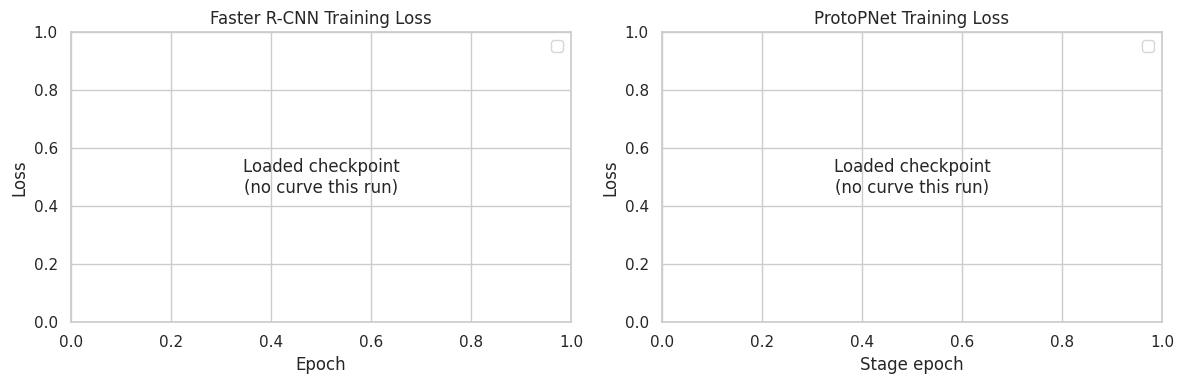

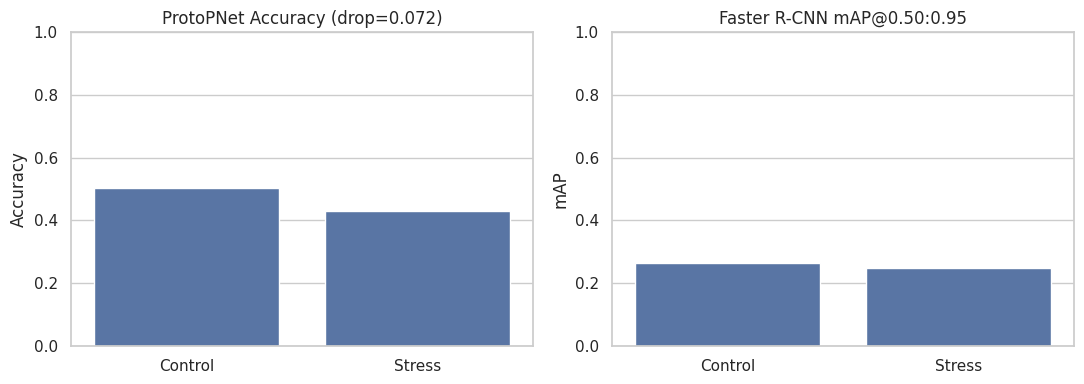

,condition,mAP@0.50:0.95,mAP@0.50,mAP@0.75,AP car,AP traffic light,AP traffic sign
0,Control,0.263186,0.547450,0.228865,0.384169,0.164455,0.240933
1,Stress,0.249197,0.530103,0.208358,0.380736,0.145628,0.221227


,class,precision@0.5_control,recall@0.5_control,tp_control,fp_control,fn_control,precision@0.5_stress,recall@0.5_stress,tp_stress,fp_stress,fn_stress
0,car,0.183749,0.845044,4041,17951,741,0.166608,0.841833,11901,59530,2236
1,traffic light,0.153473,0.721715,791,4363,305,0.148331,0.707916,3461,19872,1428
2,traffic sign,0.169433,0.729513,1184,5804,439,0.135792,0.736388,3841,24445,1375


,condition,class,precision,recall,f1,support
0,Control,background,0.000000,0.000000,0.000000,1
1,Control,car,0.496000,0.894231,0.638079,208
2,Control,traffic light,0.574468,0.252336,0.350649,107
3,Control,traffic sign,0.461538,0.090909,0.151899,132
4,Control,macro avg,0.383002,0.309369,0.285157,448
5,Control,weighted avg,0.503480,0.502232,0.424756,448
6,Stress,background,0.000000,0.000000,0.000000,0
7,Stress,car,0.433191,0.790373,0.559648,644
8,Stress,traffic light,0.401316,0.279817,0.329730,436
9,Stress,traffic sign,0.506849,0.078390,0.135780,472


,model,metric,Control,Stress,Cleaned Stress
0,Faster R-CNN,mAP@0.50:0.95,0.263186,0.249197,0.223084
1,ProtoPNet,Accuracy,0.502232,0.430412,0.413015


,model,mean_ssim,mean_cosine_similarity,drift_score
0,fasterrcnn,0.837170,0.053569,0.946431
1,proto,0.542947,0.500713,0.499287


In [30]:
def plot_training_curves(faster_history, proto_history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    if faster_history:
        ax[0].plot(range(1, len(faster_history) + 1), faster_history, marker="o", label="Faster R-CNN")
    else:
        ax[0].text(0.5, 0.5, "Loaded checkpoint\n(no curve this run)", ha="center", va="center")
    ax[0].set_title("Faster R-CNN Training Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()
    offset = 0
    for stage, values in proto_history.items():
        if values:
            xs = list(range(offset + 1, offset + len(values) + 1)); ax[1].plot(xs, values, marker="o", label=stage); offset += len(values)
    if offset == 0:
        ax[1].text(0.5, 0.5, "Loaded checkpoint\n(no curve this run)", ha="center", va="center")
    ax[1].set_title("ProtoPNet Training Loss"); ax[1].set_xlabel("Stage epoch"); ax[1].set_ylabel("Loss"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_training_curves(fasterrcnn_loss_history, protopnet_loss_history)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=["Control", "Stress"], y=[acc_ctrl, acc_stress], ax=ax[0]); ax[0].set_title(f"ProtoPNet Accuracy (drop={acc_ctrl - acc_stress:.3f})"); ax[0].set_ylim(0, 1); ax[0].set_ylabel("Accuracy")
sns.barplot(x=["Control", "Stress"], y=[float(ctrl_map_result["map"]), float(stress_map_result["map"])], ax=ax[1]); ax[1].set_title("Faster R-CNN mAP@0.50:0.95"); ax[1].set_ylim(0, 1); ax[1].set_ylabel("mAP")
plt.tight_layout(); plt.show()
display(faster_map_table); display(faster_pr_table); display(proto_metrics_table); display(weather_ablation_table); display(drift_summary_table)


,model,metric,Original Stress,MPRNet Derained Stress,change
0,Faster R-CNN,mAP@0.50:0.95,0.249197,0.246640,-0.002557
1,ProtoPNet,Accuracy,0.430412,0.413015,-0.017397


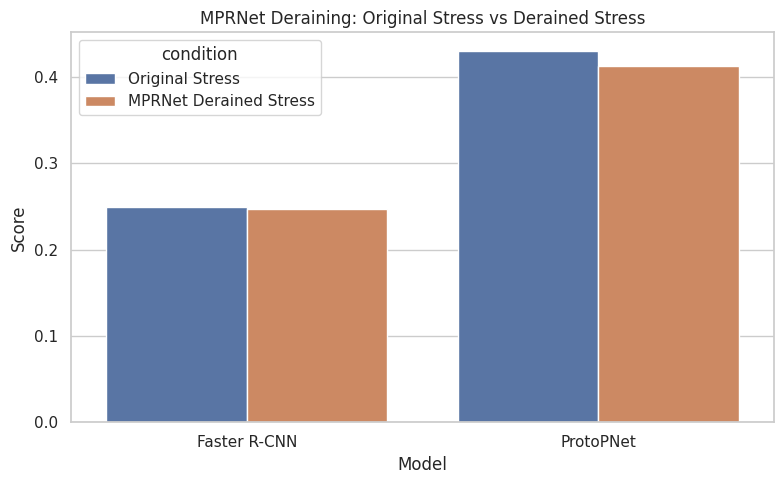

In [34]:
# ============================
# MPRNet Deraining + Evaluation
# ============================

import os, sys, importlib.util
from pathlib import Path
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 1. Clone official MPRNet repo once
# Run this cell once in Kaggle if repo is not already present.
if not os.path.exists("/kaggle/working/MPRNet"):
    !git clone -q https://github.com/swz30/MPRNet.git /kaggle/working/MPRNet

MPRNET_REPO = Path("/kaggle/working/MPRNet")
MPRNET_WEIGHTS = Path("/kaggle/working/model_deraining.pth")  # put pretrained deraining weights here


def load_mprnet_derainer(repo_dir, weights_path, device):
    """
    Loads official MPRNet deraining model.

    Expected weights:
        model_deraining.pth

    Put the checkpoint at:
        /kaggle/working/model_deraining.pth
    """
    repo_dir = Path(repo_dir)
    weights_path = Path(weights_path)

    model_file = repo_dir / "Deraining" / "MPRNet.py"
    if not model_file.exists():
        raise FileNotFoundError(f"Could not find MPRNet model file: {model_file}")

    if not weights_path.exists():
        raise FileNotFoundError(
            f"Missing MPRNet deraining weights: {weights_path}\n"
            "Download the official MPRNet deraining checkpoint and upload/place it there."
        )

    spec = importlib.util.spec_from_file_location("mprnet_deraining", model_file)
    mprnet_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mprnet_module)

    model = mprnet_module.MPRNet()
    checkpoint = torch.load(weights_path, map_location=device)

    # Handles both raw state_dict and wrapped checkpoints.
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]

    # Remove DataParallel prefix if present.
    clean_state = {}
    for k, v in checkpoint.items():
        clean_state[k.replace("module.", "")] = v

    model.load_state_dict(clean_state, strict=True)
    model = model.to(device).eval()
    return model


def _is_imagenet_normalized(x):
    return bool(x.min() < -0.1 or x.max() > 1.1)


def _denormalize_imagenet(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)


def _normalize_imagenet(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(3, 1, 1)
    return (x - mean) / std


@torch.no_grad()
def derain_tensor_mprnet(mprnet, img_tensor, device, return_normalized=None):
    """
    Derains one image tensor using MPRNet.

    Input:
        img_tensor: CHW tensor.
        Can be either:
          - Faster R-CNN image: [0,1]
          - ProtoPNet image: ImageNet-normalized

    Output:
        Same format as input unless return_normalized is set manually.
    """
    was_normalized = _is_imagenet_normalized(img_tensor)

    x = img_tensor.detach().clone().to(device)
    if was_normalized:
        x = _denormalize_imagenet(x)

    x = x.clamp(0, 1).unsqueeze(0)

    _, _, h, w = x.shape

    # MPRNet expects dimensions divisible by 8.
    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8

    if pad_h or pad_w:
        x = F.pad(x, (0, pad_w, 0, pad_h), mode="reflect")

    restored = mprnet(x)

    # Official MPRNet returns multi-stage outputs.
    if isinstance(restored, (list, tuple)):
        restored = restored[0]

    restored = restored[:, :, :h, :w].clamp(0, 1).squeeze(0).detach().cpu()

    if return_normalized is None:
        return_normalized = was_normalized

    if return_normalized:
        restored = _normalize_imagenet(restored)

    return restored


class MPRNetDerainedDataset(Dataset):
    """
    Wraps an existing dataset and derains images on the fly.

    Important:
        Use num_workers=0 because this calls a GPU model inside __getitem__.
    """
    def __init__(self, base_dataset, mprnet, device, return_normalized=None):
        self.base_dataset = base_dataset
        self.mprnet = mprnet
        self.device = device
        self.return_normalized = return_normalized

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, target = self.base_dataset[idx]
        derained_img = derain_tensor_mprnet(
            self.mprnet,
            img,
            self.device,
            return_normalized=self.return_normalized
        )
        return derained_img, target


# 2. Load MPRNet
mprnet_derainer = load_mprnet_derainer(
    repo_dir=MPRNET_REPO,
    weights_path=MPRNET_WEIGHTS,
    device=device
)

# 3. Create MPRNet-derained stress datasets
# Faster R-CNN uses [0,1] tensors.
mprnet_derained_stress_det = MPRNetDerainedDataset(
    stress_det,
    mprnet_derainer,
    device,
    return_normalized=False
)

# ProtoPNet uses ImageNet-normalized tensors.
mprnet_derained_stress_B = MPRNetDerainedDataset(
    full_stress_B,
    mprnet_derainer,
    device,
    return_normalized=True
)

# 4. DataLoaders
# Keep num_workers=0 because deraining happens inside Dataset.
mprnet_derained_stress_loader_det = DataLoader(
    mprnet_derained_stress_det,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

mprnet_derained_stress_loader_B = DataLoader(
    mprnet_derained_stress_B,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

# 5. Evaluate Faster R-CNN on MPRNet-derained stress images
mprnet_derained_map_result = evaluate_detection_map(
    model_A,
    mprnet_derained_stress_loader_det,
    device
)

# 6. Evaluate ProtoPNet on MPRNet-derained stress images
mprnet_derained_acc = eval_acc(
    model_B,
    mprnet_derained_stress_loader_B,
    device
)

# 7. Report comparison
mprnet_weather_ablation_table = pd.DataFrame([
    {
        "model": "Faster R-CNN",
        "metric": "mAP@0.50:0.95",
        "Original Stress": float(stress_map_result["map"]),
        "MPRNet Derained Stress": float(mprnet_derained_map_result["map"]),
        "change": float(mprnet_derained_map_result["map"] - stress_map_result["map"]),
    },
    {
        "model": "ProtoPNet",
        "metric": "Accuracy",
        "Original Stress": acc_stress,
        "MPRNet Derained Stress": mprnet_derained_acc,
        "change": mprnet_derained_acc - acc_stress,
    }
])

display(mprnet_weather_ablation_table)

plot_df = mprnet_weather_ablation_table.melt(
    id_vars=["model", "metric", "change"],
    value_vars=["Original Stress", "MPRNet Derained Stress"],
    var_name="condition",
    value_name="score"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="condition")
plt.title("MPRNet Deraining: Original Stress vs Derained Stress")
plt.ylabel("Score")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


In [33]:
# Download official MPRNet deraining pretrained weights
!pip install -q gdown

import os
import gdown

MPRNET_WEIGHTS = "/kaggle/working/model_deraining.pth"

if not os.path.exists(MPRNET_WEIGHTS):
    # Official MPRNet deraining checkpoint from swz30/MPRNet README
    file_id = "1O3WEJbcat7eTY6doXWeorAbQ1l_WmMnM"
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, MPRNET_WEIGHTS, quiet=False)

print("Exists:", os.path.exists(MPRNET_WEIGHTS))
print("Path:", MPRNET_WEIGHTS)


Exists: True
Path: /kaggle/working/model_deraining.pth
